# Le modèle appris bat-il une table de règles ? — NIST 14 & 16 SEER

Le FDD par résidus a une méthode de référence dans le domaine : une **table de signes**.
Sous-refroidissement qui monte et pression haute qui monte, c'est une obstruction de
condenseur. Le projet cite Li & Braun, construit les résidus, puis pose un Gradient
Boosting dessus — sans avoir jamais implémenté la table.

Ici la table vote, sans entraînement. Les signes de chaque défaut sont estimés **sur la
machine d'entraînement seulement** (même régression sur le niveau de défaut que
l'accord simulation/mesure). Aucun seuil n'est choisi sur la machine de test.

Trois protocoles, identiques à `EDA_NIST_calibration.ipynb` / `EDA_NIST_perclass.ipynb` :

| | Référence saine | Ce que ça teste |
|---|---|---|
| Calibrée | kNN, sains de la machine cible | La table a-t-elle besoin du GB ? |
| Transférée | kNN, sains de la machine d'entraînement | La table survit-elle au changement d'unité ? |
| **Sans référence** | médiane globale des sains d'entraînement | Une direction brute, sans condition équivalente |

Le modèle appris n'a pas d'équivalent « sans référence » : un GB travaille sur des
*valeurs*. Un arbre de profondeur 3 se place entre la règle écrite et les centaines
d'arbres du boosting.

Chargement, étiquetage (tolérance 2 %), `1701` pas `1710`, huit résidus,
`GradientBoostingClassifier(random_state=42)` : **identiques** aux notebooks précédents.

> **Données non versionnées.** `fdd_1416seer.xlsx` dans `data/nist/`.


## 0 — Jeu


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'requirements.txt').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
NIST = ROOT / 'data' / 'nist'
assert (NIST / 'fdd_1416seer.xlsx').exists(), 'Placer les xlsx NIST dans data/nist/ (non versionnés).'

BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, MUTED, GRID = '#0b0b0b', '#52514e', '#e4e3df'
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white', 'axes.edgecolor': GRID,
    'axes.labelcolor': MUTED, 'text.color': INK, 'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 10,
})

F2C = lambda s: (s - 32) * 5 / 9
dF2K = lambda s: s * 5 / 9
PSI2BAR, BTU2W = 0.0689476, 0.293071

df0 = pd.read_excel(NIST / 'fdd_1416seer.xlsx')
FAULTCOLS = {'EF': 'Evap_Airflow', 'CF': 'Cond_Blockage', 'LL': 'LiquidLine', 'UC/OC': 'Charge'}

def fault_label(row, tol=2.0):
    active = []
    for col, name in FAULTCOLS.items():
        v = row[col]
        if pd.isna(v) or abs(v - 100) <= tol:
            continue
        if name == 'Charge':
            name = 'Undercharge' if v < 100 else 'Overcharge'
        active.append(name)
    if not active:
        return 'No_Fault'
    return active[0] if len(active) == 1 else 'MULTI:' + '+'.join(sorted(active))

df0['fault_class'] = df0.apply(fault_label, axis=1)
m16 = df0.Rated_SEER == 16.0
assert (df0.loc[m16, '1710_ODSuctPort_psia'] == df0.loc[m16, 'CompDisch_psia']).all()

X = pd.DataFrame(index=df0.index)
X['P_evap'] = df0['1701_ODVapSV_psia'] * PSI2BAR
X['P_cond'] = df0['CompDisch_psia'] * PSI2BAR
X['pressure_ratio'] = X.P_cond / X.P_evap
X['T_suction'] = F2C(df0['1608_CompSuct_TempF'])
X['T_discharge'] = F2C(df0['1617_CompDisch_TempF'])
X['T_evap'] = F2C(df0['CompSuct_Tsat_F'])
X['T_cond'] = F2C(df0['CompDisch_Tsat_F'])
X['superheat'] = dF2K(df0['CompSuct_Suph_F'])
X['subcooling'] = dF2K(df0['ODLiqSV_Tsub_F'])
X['Q_evap'] = df0['TOTAL Capacity (Btu/h)'] * BTU2W
X['W_od'] = df0['OD_Xitron_Watts']
X['COP'] = df0['COP']
X['T_source'] = F2C(df0['Inlet TC Grid AVG Temp (F)'])
X['T_sink'] = F2C(df0['OD Air AVG DB (F)'])

LEAK = ['EF', 'CF', 'LL', 'UC/OC', 'NF']
assert not any(c in X.columns for c in LEAK)

y, grp = df0.fault_class, df0.Rated_SEER
keep = grp.isin([14.0, 16.0]) & (~y.str.startswith('MULTI')) & X.notna().all(axis=1)
X, y, grp, df = X.loc[keep].copy(), y.loc[keep].copy(), grp.loc[keep].copy(), df0.loc[keep].copy()

RES = ['superheat', 'subcooling', 'T_discharge', 'COP', 'W_od', 'P_evap', 'P_cond', 'pressure_ratio']
COND = ['T_source', 'T_sink']
LABELS = ['No_Fault', 'Undercharge', 'Overcharge', 'Evap_Airflow', 'LiquidLine', 'Cond_Blockage']
FR = {
    'No_Fault': 'sans défaut', 'Undercharge': 'sous-charge', 'Overcharge': 'surcharge',
    'Evap_Airflow': 'débit intérieur', 'LiquidLine': 'ligne liquide',
    'Cond_Blockage': 'obstruction condenseur',
}
NIVEAU = {
    'Cond_Blockage': 100 - df.CF, 'Evap_Airflow': 100 - df.EF,
    'Undercharge': 100 - df['UC/OC'], 'Overcharge': df['UC/OC'] - 100,
    'LiquidLine': 100 - df.LL,
}
SYM = {1: '+', -1: '−', 0: '0'}

print(f'{len(X)} lignes · {y.nunique()} classes')
print(dict(y.value_counts()))


5386 lignes · 6 classes
{'No_Fault': np.int64(1352), 'Undercharge': np.int64(1228), 'Overcharge': np.int64(942), 'Evap_Airflow': np.int64(774), 'LiquidLine': np.int64(593), 'Cond_Blockage': np.int64(497)}


## 1 — La table de signes, estimée sur le train

Pour chaque défaut, régression du niveau (avec `T_source`, `T_sink` en covariables) sur
la **machine d'entraînement**. Le signe du coefficient est le vote attendu. `No_Fault`
vote 0 partout : il gagne si aucun défaut n'a un score strictement positif. Pas de seuil
cherché, pas de pondération.


In [2]:
def knn_predict(Xh_cond, Xh_res, X_cond, k=5):
    k = min(int(k), len(Xh_cond))
    tree = cKDTree(np.asarray(Xh_cond, dtype=float))
    _, idx = tree.query(np.asarray(X_cond, dtype=float), k=k)
    if idx.ndim == 1:
        idx = idx[:, None]
    return np.median(np.asarray(Xh_res)[idx], axis=1)


def sgn(x, eps=1e-4):
    return 0 if abs(x) < eps else (1 if x > 0 else -1)


def signs_from_train(tr):
    table = {}
    for cls in LABELS:
        if cls == 'No_Fault':
            table[cls] = np.zeros(len(RES), dtype=int)
            continue
        m = ((y == cls) | (y == 'No_Fault')) & tr
        lvl = NIVEAU[cls].where(y == cls, 0.0)[m]
        vec = []
        for col in RES:
            d = pd.concat([lvl.rename('lvl'), X.loc[m, [col, 'T_source', 'T_sink']]], axis=1).dropna()
            A = np.c_[np.ones(len(d)), d.lvl, d.T_source, d.T_sink]
            b = np.linalg.lstsq(A, d[col].values, rcond=None)[0][1]
            vec.append(sgn(b))
        table[cls] = np.array(vec, dtype=int)
    return table


def vote(R, table):
    sr = np.sign(R)
    scores = np.zeros((len(R), len(LABELS)))
    for i, cls in enumerate(LABELS):
        if cls == 'No_Fault':
            continue
        scores[:, i] = (sr * table[cls]).sum(axis=1)
    hat_i = scores.argmax(axis=1)
    hat_i[scores.max(axis=1) <= 0] = LABELS.index('No_Fault')
    return np.array(LABELS)[hat_i]


folds = []
for test_seer in (14.0, 16.0):
    tr = (grp != test_seer)
    te = (grp == test_seer)
    h_tr = tr & (y == 'No_Fault')
    h_te = te & (y == 'No_Fault')
    pred_tr = knn_predict(X.loc[h_tr, COND], X.loc[h_tr, RES], X.loc[tr, COND])
    Dtr = X.loc[tr, RES].to_numpy() - pred_tr
    gb = GradientBoostingClassifier(random_state=42).fit(Dtr, y.loc[tr])
    dt = DecisionTreeClassifier(max_depth=3, random_state=42).fit(Dtr, y.loc[tr])
    table = signs_from_train(tr)
    folds.append(dict(
        test=int(test_seer), tr=tr, te=te, h_tr=h_tr, h_te=h_te,
        gb=gb, dt=dt, table=table,
    ))
    train_seer = 16 if test_seer == 14 else 14
    print(f'signes estimés sur la {train_seer} SEER (test = {int(test_seer)})')
    rows = [{'défaut': FR[c], **{RES[i]: SYM[int(v[i])] for i in range(8)}} for c, v in table.items()]
    print(pd.DataFrame(rows).set_index('défaut').to_string())
    print()


signes estimés sur la 16 SEER (test = 14)
                       superheat subcooling T_discharge COP W_od P_evap P_cond pressure_ratio
défaut                                                                                       
sans défaut                    0          0           0   0    0      0      0              0
sous-charge                    +          −           +   −    −      −      −              +
surcharge                      −          +           +   −    +      −      +              +
débit intérieur                +          +           +   −    +      −      −              +
ligne liquide                  −          −           −   −    −      +      −              −
obstruction condenseur         +          −           +   −    +      −      +              +

signes estimés sur la 14 SEER (test = 16)
                       superheat subcooling T_discharge COP W_od P_evap P_cond pressure_ratio
défaut                                                               

Les deux machines ne racontent pas la même physique pour le débit d'air : les signes
s'inversent d'un pli à l'autre. Une table universelle héritée de la campagne entière
fuirait la machine de test ; ici chaque pli n'a le droit qu'à la sienne.


In [3]:
def class_metrics(yte, hat):
    p, r, f1, s = precision_recall_fscore_support(yte, hat, labels=LABELS, zero_division=0)
    return dict(
        acc=accuracy_score(yte, hat),
        f1m=f1_score(yte, hat, average='macro'),
        f1=f1, precision=p, recall=r, support=s,
    )


def R_cal(f):
    pred = knn_predict(X.loc[f['h_te'], COND], X.loc[f['h_te'], RES], X.loc[f['te'], COND])
    return X.loc[f['te'], RES].to_numpy() - pred


def R_trf(f):
    pred = knn_predict(X.loc[f['h_tr'], COND], X.loc[f['h_tr'], RES], X.loc[f['te'], COND])
    return X.loc[f['te'], RES].to_numpy() - pred


def R_none(f):
    med = X.loc[f['h_tr'], RES].median().to_numpy()
    return X.loc[f['te'], RES].to_numpy() - med


def evaluate(name, residual_fn, kind):
    accs, f1s, per = [], [], []
    for f in folds:
        R = residual_fn(f)
        if kind == 'rules':
            hat = vote(R, f['table'])
        elif kind == 'gb':
            hat = f['gb'].predict(R)
        else:
            hat = f['dt'].predict(R)
        yte = y.loc[X.index[f['te']]]
        m = class_metrics(yte, hat)
        accs.append(m['acc']); f1s.append(m['f1m']); per.append(m)
        print(f'{name:22s} → {f["test"]} SEER  acc={m["acc"]:.3f}  F1={m["f1m"]:.3f}')
    mean_acc, mean_f1 = float(np.mean(accs)), float(np.mean(f1s))
    print(f'{name:22s} MEAN acc={mean_acc:.3f}  F1 macro={mean_f1:.3f}')
    f1_cls = {lab: float(np.mean([p['f1'][i] for p in per])) for i, lab in enumerate(LABELS)}
    return dict(name=name, acc=mean_acc, f1=mean_f1, f1_cls=f1_cls, per=per)


results = []
print('contrôle GB')
results.append(evaluate('GB calibré', R_cal, 'gb'))
results.append(evaluate('GB transféré', R_trf, 'gb'))


contrôle GB
GB calibré             → 14 SEER  acc=0.637  F1=0.477
GB calibré             → 16 SEER  acc=0.568  F1=0.481
GB calibré             MEAN acc=0.602  F1 macro=0.479
GB transféré           → 14 SEER  acc=0.209  F1=0.251
GB transféré           → 16 SEER  acc=0.427  F1=0.329
GB transféré           MEAN acc=0.318  F1 macro=0.290


In [4]:
ACC_CAL, F1_CAL, ACC_TRF, F1_TRF = 0.602, 0.479, 0.318, 0.290
gb_cal = next(r for r in results if r['name'] == 'GB calibré')
gb_trf = next(r for r in results if r['name'] == 'GB transféré')
ok = (
    abs(gb_cal['acc'] - ACC_CAL) < 0.005 and abs(gb_cal['f1'] - F1_CAL) < 0.005
    and abs(gb_trf['acc'] - ACC_TRF) < 0.005 and abs(gb_trf['f1'] - F1_TRF) < 0.005
)
print(f"GB calibré    {gb_cal['acc']:.3f} / {gb_cal['f1']:.3f}   cible {ACC_CAL:.3f} / {F1_CAL:.3f}")
print(f"GB transféré  {gb_trf['acc']:.3f} / {gb_trf['f1']:.3f}   cible {ACC_TRF:.3f} / {F1_TRF:.3f}")
if not ok:
    raise RuntimeError('bornes GB non retrouvées — on s\'arrête.')
print('bornes OK.')


GB calibré    0.602 / 0.479   cible 0.602 / 0.479
GB transféré  0.318 / 0.290   cible 0.318 / 0.290
bornes OK.


## 2 — Règles, arbre de profondeur 3, boosting


In [5]:
print('règles')
results.append(evaluate('Règles calibrées', R_cal, 'rules'))
results.append(evaluate('Règles transférées', R_trf, 'rules'))
results.append(evaluate('Règles sans référence', R_none, 'rules'))
print()
print('arbre profondeur 3')
results.append(evaluate('DT3 calibré', R_cal, 'dt'))
results.append(evaluate('DT3 transféré', R_trf, 'dt'))
results.append(evaluate('DT3 sans référence', R_none, 'dt'))

by_name = {r['name']: r for r in results}
summary = pd.DataFrame([
    {'méthode': r['name'], 'accuracy': round(r['acc'], 3), 'F1 macro': round(r['f1'], 3)}
    for r in by_name.values()
]).set_index('méthode')
summary.loc['classe majoritaire'] = [0.251, float('nan')]
summary


règles
Règles calibrées       → 14 SEER  acc=0.292  F1=0.203
Règles calibrées       → 16 SEER  acc=0.437  F1=0.283
Règles calibrées       MEAN acc=0.365  F1 macro=0.243
Règles transférées     → 14 SEER  acc=0.248  F1=0.170
Règles transférées     → 16 SEER  acc=0.254  F1=0.179
Règles transférées     MEAN acc=0.251  F1 macro=0.175
Règles sans référence  → 14 SEER  acc=0.237  F1=0.190
Règles sans référence  → 16 SEER  acc=0.254  F1=0.204
Règles sans référence  MEAN acc=0.245  F1 macro=0.197

arbre profondeur 3
DT3 calibré            → 14 SEER  acc=0.620  F1=0.413
DT3 calibré            → 16 SEER  acc=0.497  F1=0.431
DT3 calibré            MEAN acc=0.558  F1 macro=0.422
DT3 transféré          → 14 SEER  acc=0.221  F1=0.216
DT3 transféré          → 16 SEER  acc=0.353  F1=0.244
DT3 transféré          MEAN acc=0.287  F1 macro=0.230
DT3 sans référence     → 14 SEER  acc=0.315  F1=0.301
DT3 sans référence     → 16 SEER  acc=0.364  F1=0.311
DT3 sans référence     MEAN acc=0.340  F1 macro=0.306


,accuracy,F1 macro
méthode,,
GB calibré,0.602,0.479
GB transféré,0.318,0.290
Règles calibrées,0.365,0.243
Règles transférées,0.251,0.175
Règles sans référence,0.245,0.197
DT3 calibré,0.558,0.422
DT3 transféré,0.287,0.230
DT3 sans référence,0.340,0.306
classe majoritaire,0.251,NaN


## 3 — Détail par panne

Le GB est mauvais sur quatre pannes sur six. Une règle qui gagnerait sur la ligne liquide
serait invisible dans la moyenne.


In [6]:
wanted = ['GB calibré', 'DT3 calibré', 'Règles calibrées',
          'GB transféré', 'Règles transférées', 'Règles sans référence']
by_name = {r['name']: r for r in results}
rows = []
for lab in LABELS:
    rec = {'classe': FR[lab]}
    for name in wanted:
        rec[name] = round(by_name[name]['f1_cls'][lab], 3)
    rows.append(rec)
perclass = pd.DataFrame(rows).set_index('classe')
perclass


,GB calibré,DT3 calibré,Règles calibrées,GB transféré,Règles transférées,Règles sans référence
classe,,,,,,
sans défaut,0.741,0.655,0.113,0.131,0.050,0.102
sous-charge,0.832,0.905,0.594,0.481,0.484,0.418
surcharge,0.674,0.576,0.440,0.786,0.237,0.252
débit intérieur,0.288,0.127,0.102,0.269,0.192,0.261
ligne liquide,0.040,0.087,0.136,0.007,0.000,0.081
obstruction condenseur,0.299,0.183,0.072,0.067,0.085,0.069


figure → docs/nist_rules_vs_gb.png


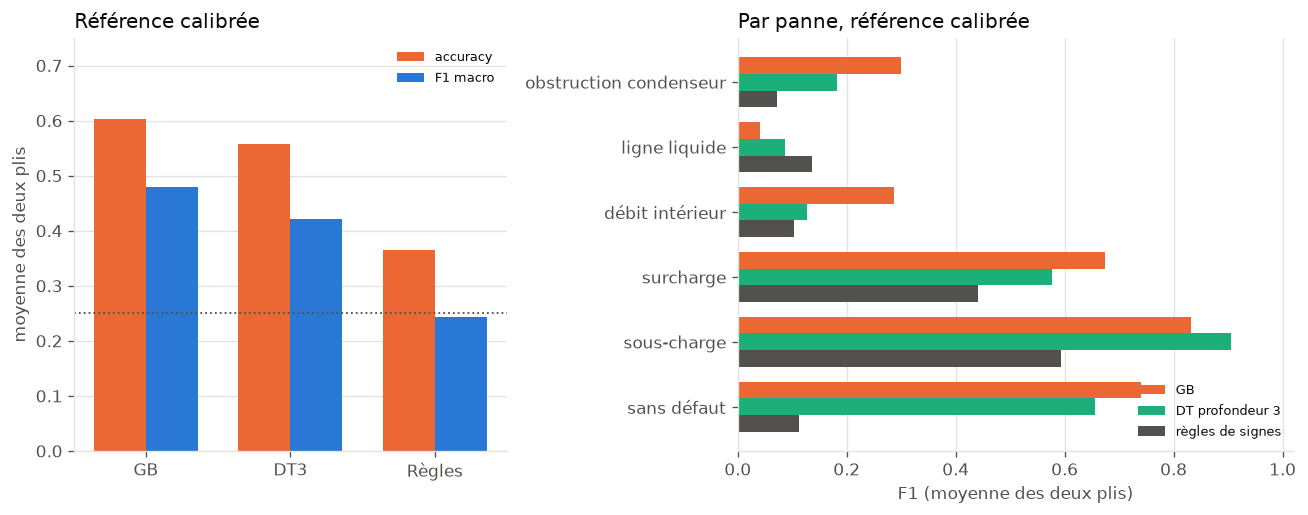

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.4), gridspec_kw={'width_ratios': [1.05, 1.35]})

# global scores, calibrated + transferred rules
ax = axes[0]
names = ['GB', 'DT3', 'Règles']
acc_c = [next(r['acc'] for r in results if r['name'] == n) for n in ['GB calibré', 'DT3 calibré', 'Règles calibrées']]
f1_c = [next(r['f1'] for r in results if r['name'] == n) for n in ['GB calibré', 'DT3 calibré', 'Règles calibrées']]
x = np.arange(3); w = 0.36
ax.bar(x - w/2, acc_c, width=w, color=ORANGE, label='accuracy')
ax.bar(x + w/2, f1_c, width=w, color=BLUE, label='F1 macro')
ax.axhline(0.251, color=MUTED, ls=':', lw=1.1)
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylim(0, 0.75); ax.set_ylabel('moyenne des deux plis')
ax.set_title('Référence calibrée', loc='left', color=INK)
ax.legend(frameon=False, fontsize=8)
ax.grid(axis='x', visible=False)

ax = axes[1]
ypos = np.arange(len(LABELS))
h = 0.26
gb = [next(r['f1_cls'][lab] for r in results if r['name'] == 'GB calibré') for lab in LABELS]
dt = [next(r['f1_cls'][lab] for r in results if r['name'] == 'DT3 calibré') for lab in LABELS]
ru = [next(r['f1_cls'][lab] for r in results if r['name'] == 'Règles calibrées') for lab in LABELS]
ax.barh(ypos + h, gb, height=h, color=ORANGE, label='GB')
ax.barh(ypos, dt, height=h, color=AQUA, label='DT profondeur 3')
ax.barh(ypos - h, ru, height=h, color=MUTED, label='règles de signes')
ax.set_yticks(ypos)
ax.set_yticklabels([FR[l] for l in LABELS])
ax.set_xlim(0, 1.02); ax.set_xlabel('F1 (moyenne des deux plis)')
ax.set_title('Par panne, référence calibrée', loc='left', color=INK)
ax.legend(frameon=False, fontsize=8, loc='lower right')
ax.grid(axis='y', visible=False)

fig.tight_layout()
fig_path = ROOT / 'docs' / 'nist_rules_vs_gb.png'
fig.savefig(fig_path, dpi=140, bbox_inches='tight')
print('figure →', fig_path.relative_to(ROOT))


In [8]:
print('arbre de profondeur 3, pli test = 16 SEER (entraîné sur la 14)')
print(export_text(folds[1]['dt'], feature_names=['d_' + c for c in RES], decimals=2))


arbre de profondeur 3, pli test = 16 SEER (entraîné sur la 14)
|--- d_subcooling <= -1.24
|   |--- d_W_od <= 83.63
|   |   |--- d_subcooling <= -1.53
|   |   |   |--- class: Undercharge
|   |   |--- d_subcooling >  -1.53
|   |   |   |--- class: Undercharge
|   |--- d_W_od >  83.63
|   |   |--- class: Cond_Blockage
|--- d_subcooling >  -1.24
|   |--- d_P_cond <= 1.43
|   |   |--- d_P_cond <= 0.23
|   |   |   |--- class: No_Fault
|   |   |--- d_P_cond >  0.23
|   |   |   |--- class: Evap_Airflow
|   |--- d_P_cond >  1.43
|   |   |--- d_subcooling <= 4.52
|   |   |   |--- class: Cond_Blockage
|   |   |--- d_subcooling >  4.52
|   |   |   |--- class: Overcharge



## Ce que ça dit

**Le Gradient Boosting gagne sa place**, mais pas sur toutes les pannes, et pas de beaucoup
contre un arbre de profondeur 3.

**Moyenne, référence calibrée.** GB 0,602 / 0,479 ; arbre de profondeur 3 : 0,558 / 0,422
(quatre points d'accuracy, six de F1) ; table de signes : 0,365 / 0,243. La table est
au-dessus de la classe majoritaire (0,251), loin du modèle. Les centaines d'arbres du
boosting achètent ~4 points contre un seul arbre — ce n'est pas rien, ce n'est pas un
gouffre non plus.

**Sans référence conditionnelle, la table ne vaut plus rien** (0,245 / 0,197) : autant
tirer la classe majoritaire. Une règle de signes a besoin d'un écart à un cycle sain *à
condition équivalente*. Ce n'est pas le GB qui justifie Li & Braun, c'est ce résultat.

**Transférée**, la table (0,251) retombe au hasard des effectifs. Les signes du débit d'air
s'inversent d'une machine à l'autre : il n'y a pas de table universelle à extraire de ce
jeu.

**Ligne liquide — la règle bat le modèle.** F1 0,136 contre 0,040 pour le GB, 0,087 pour
l'arbre. Toujours faible, mais c'est la seule panne où voter des signes fait mieux que
centaines d'arbres. Le boosting a appris à ignorer une classe que la physique nomme.

**Sous-charge**, l'arbre de profondeur 3 (F1 0,91) bat même le GB (0,83) : un seuil sur
deux ou trois résidus suffit. Le modèle appris justifie surtout le **sans-défaut** et,
dans une moindre mesure, la surcharge — là où une direction unique ne tranche pas.
